### Stroke Prediction Dataset - Acidente Vascular Cerebral
* https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

*  Stroke is a medical emergency. A stroke occurs when blood flow to a part of your brain is interrupted or reduced, preventing brain tissue from getting oxygen and nutrients. Brain cells begin to die within minutes

* Age: People aged 55 years and over

* Hypertension: if the systolic pressure is 140 mm Hg or more, or the diastolic pressure is 90 mm Hg or more

* Hypercholesterolemia: If the cholesterol level in the blood is 200 milligrams per deciliter

* Smoking

* Diabetes

* Obesity: if the body mass index (BMI) is 30 or more



In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
# Carrega a base de dados
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Limpeza e Normalização

In [4]:
# formato dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [5]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
df.shape

(5110, 12)

Limpeza do atributo BMI

In [7]:
media = df['bmi'].mean()

In [8]:
media

np.float64(28.893236911794666)

In [11]:
df['bmi'] = df['bmi'].fillna(media)

In [12]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Normalização com StandardScaler()

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [14]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [15]:
columns = ['age', 'avg_glucose_level', 'bmi']

In [16]:
scaler = StandardScaler()

In [19]:
df[columns] = scaler.fit_transform(df[columns])

In [20]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,1.051434,0,1,Yes,Private,Urban,2.706375,1.001234e+00,formerly smoked,1
1,51676,Female,0.786070,0,0,Yes,Self-employed,Rural,2.121559,4.615554e-16,never smoked,1
2,31112,Male,1.626390,0,1,Yes,Private,Rural,-0.005028,4.685773e-01,never smoked,1
3,60182,Female,0.255342,0,0,Yes,Private,Urban,1.437358,7.154182e-01,smokes,1
4,1665,Female,1.582163,1,0,Yes,Self-employed,Rural,1.501184,-6.357112e-01,never smoked,1


#### Transformação dos atributos categóricos

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [22]:
# smoking_status
df['smoking_status'].unique()

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [23]:
# Residence_type
df['Residence_type'].unique()

<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str

In [24]:
# work_type
df['work_type'].unique()

<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str

In [25]:
# ever_married
df['ever_married'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [26]:
# gender
df['gender'].unique()

<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

Transformação com LabelEncoder
  - Residence_type
  - gender
  - ever-married

In [27]:
labelEncoder = LabelEncoder()

In [28]:
df['Residence_type'] = labelEncoder.fit_transform(df['Residence_type'])
df['Residence_type'].unique()

array([1, 0])

In [29]:
df['gender'] = labelEncoder.fit_transform(df['gender'])
df['gender'].unique()

array([1, 0, 2])

In [30]:
df['ever_married'] = labelEncoder.fit_transform(df['ever_married'])
df['ever_married'].unique()

array([1, 0])

In [31]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,1.051434,0,1,1,Private,1,2.706375,1.001234e+00,formerly smoked,1
1,51676,0,0.786070,0,0,1,Self-employed,0,2.121559,4.615554e-16,never smoked,1
2,31112,1,1.626390,0,1,1,Private,0,-0.005028,4.685773e-01,never smoked,1
3,60182,0,0.255342,0,0,1,Private,1,1.437358,7.154182e-01,smokes,1
4,1665,0,1.582163,1,0,1,Self-employed,0,1.501184,-6.357112e-01,never smoked,1


Transformação com get dummies

In [35]:
df['smoking_status'].unique()

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [36]:
df = pd.get_dummies(data = df, columns=['smoking_status'])

In [37]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='str')

In [38]:
df = pd.get_dummies(data = df, columns=['work_type'])

In [39]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes',
       'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children'],
      dtype='str')

In [40]:
df.shape

(5110, 19)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              5110 non-null   int64  
 1   gender                          5110 non-null   int64  
 2   age                             5110 non-null   float64
 3   hypertension                    5110 non-null   int64  
 4   heart_disease                   5110 non-null   int64  
 5   ever_married                    5110 non-null   int64  
 6   Residence_type                  5110 non-null   int64  
 7   avg_glucose_level               5110 non-null   float64
 8   bmi                             5110 non-null   float64
 9   stroke                          5110 non-null   int64  
 10  smoking_status_Unknown          5110 non-null   bool   
 11  smoking_status_formerly smoked  5110 non-null   bool   
 12  smoking_status_never smoked     5110 non-null

In [42]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,9046,1,1.051434,0,1,1,1,2.706375,1.001234e+00,1,False,True,False,False,False,False,True,False,False
1,51676,0,0.786070,0,0,1,0,2.121559,4.615554e-16,1,False,False,True,False,False,False,False,True,False
2,31112,1,1.626390,0,1,1,0,-0.005028,4.685773e-01,1,False,False,True,False,False,False,True,False,False
3,60182,0,0.255342,0,0,1,1,1.437358,7.154182e-01,1,False,False,False,True,False,False,True,False,False
4,1665,0,1.582163,1,0,1,0,1.501184,-6.357112e-01,1,False,False,True,False,False,False,False,True,False


### Amostragem: Houldout e Balanceamento das classes
* Separação entre treino e teste (70% e 30%)

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [45]:
# Separar os atributos e a classe
X = df.drop(['stroke'], axis=1)
y = df['stroke']

In [46]:
X.shape, df.shape

((5110, 18), (5110, 19))

In [49]:
# Amostragem por houldout
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [50]:
X_train.shape, X_test.shape

((4088, 18), (1022, 18))

In [ ]:
DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)
y_pred = DT.predict(X_test)


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       977
           1       0.06      0.09      0.07        45

    accuracy                           0.90      1022
   macro avg       0.51      0.51      0.51      1022
weighted avg       0.92      0.90      0.91      1022



array([[918,  59],
       [ 41,   4]])

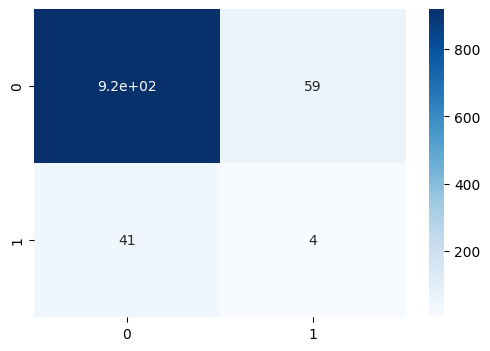

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
confusion_matrix(y_test,y_pred)

In [60]:
y_test.value_counts()

stroke
0    977
1     45
Name: count, dtype: int64

Balanceamento das classes
* https://medium.com/analytics-vidhya/undersampling-and-oversampling-an-old-and-a-new-approach-4f984a0e8392
* Abordagem SMOTE

In [61]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [62]:
from imblearn.over_sampling import SMOTE

In [63]:
sm = SMOTE()
X_balanced, y_balanced = sm.fit_resample(X, y)

In [64]:
X_balanced.shape

(9722, 18)

In [65]:
y_balanced.value_counts()

stroke
1    4861
0    4861
Name: count, dtype: int64

In [67]:
X_train,X_test,y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2)

In [68]:
X_train.shape, X_test.shape

((7777, 18), (1945, 18))

In [69]:
y_train.value_counts(), y_test.value_counts()

(stroke
 0    3903
 1    3874
 Name: count, dtype: int64,
 stroke
 1    987
 0    958
 Name: count, dtype: int64)

In [75]:
DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)
y_pred = DT.predict(X_test)


In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       958
           1       0.92      0.95      0.94       987

    accuracy                           0.93      1945
   macro avg       0.94      0.93      0.93      1945
weighted avg       0.94      0.93      0.93      1945



[[879  79]
 [ 49 938]]


<Axes: >

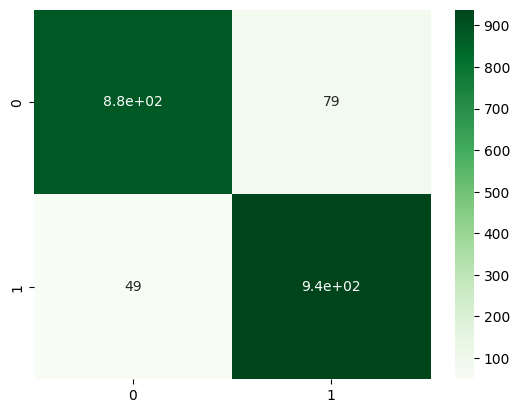

In [73]:
print(confusion_matrix(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, cmap='Greens')

## Amostragem: Validação Cruzada

In [77]:
from sklearn.model_selection import (
    KFold,
    LeaveOneOut,
    StratifiedKFold,
    cross_validate
)

### K-fold Cross-validation

In [78]:
DT = DecisionTreeClassifier()
kf = KFold(n_splits = 10, shuffle = True)
clf = cross_validate(
    DT,
    X,
    y,
    scoring = 'balanced_accuracy',
    cv = kf
)

print(f"{clf['test_score']}\nMedia: {np.mean(clf['test_score'])}")

[0.51989217 0.61046431 0.56234798 0.52018634 0.64829829 0.54642704
 0.55838531 0.57244251 0.52143224 0.49938021]
Media: 0.5559256391502886


Balanceado

In [79]:
DT = DecisionTreeClassifier()
kf = KFold(n_splits = 10, shuffle = True)
clf = cross_validate(
    DT,
    X_balanced,
    y_balanced,
    scoring = 'balanced_accuracy',
    cv = kf
)

print(f"{clf['test_score']}\nMedia: {np.mean(clf['test_score'])}")

[0.92862373 0.92471359 0.91869642 0.93136167 0.92336258 0.94029933
 0.94331809 0.9404723  0.9178773  0.93810976]
Media: 0.9306834773291071


### Stratified K-fold Cross-validation

In [80]:
DT = DecisionTreeClassifier()
skf = StratifiedKFold(n_splits = 10, shuffle = True)
clf = cross_validate(
    DT,
    X,
    y,
    scoring = 'balanced_accuracy',
    cv = skf
)

print(f"{clf['test_score']}\nMedia: {np.mean(clf['test_score'])}")

[0.53942387 0.56045267 0.59736626 0.53633745 0.55427984 0.57222222
 0.57119342 0.53736626 0.54148148 0.60343943]
Media: 0.5613562881841457


Balanceado

In [81]:
DT = DecisionTreeClassifier()
skf = StratifiedKFold(n_splits = 10, shuffle = True)
clf = cross_validate(
    DT,
    X_balanced,
    y_balanced,
    scoring = 'balanced_accuracy',
    cv = skf
)

print(f"{clf['test_score']}\nMedia: {np.mean(clf['test_score'])}")

[0.93010453 0.95170947 0.93312757 0.92798354 0.93930041 0.93004115
 0.91666667 0.93621399 0.92489712 0.93209877]
Media: 0.9322143213256606


### Leave-One-Out Cross-Validation

In [82]:
DT = DecisionTreeClassifier()
loo = LeaveOneOut()

clf = cross_validate(
    DT,
    X,
    y,
    scoring='accuracy',
    cv = loo
)

print(f"{clf['test_score']}\nMedia: {np.mean(clf['test_score'])}")

[0. 0. 1. ... 1. 1. 1.]
Media: 0.912133072407045


Balanceado

In [83]:
DT = DecisionTreeClassifier()
loo = LeaveOneOut()

clf = cross_validate(
    DT,
    X_balanced,
    y_balanced,
    scoring='accuracy',
    cv = loo
)

print(f"{clf['test_score']}\nMedia: {np.mean(clf['test_score'])}")

[0. 0. 0. ... 1. 1. 1.]
Media: 0.9300555441267229
